In [1]:
import os
import pandas as pd
from sklearn.svm import SVR
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
def load_data_from_folder(folder_path):
    csv_files = [f for f in os.listdir(folder_path) if f.endswith('.csv')]
    data_list = [pd.read_csv(os.path.join(folder_path, file)) for file in csv_files]
    combined_data = pd.concat(data_list, ignore_index=True)
    return combined_data


In [3]:
train_folder = r'C:\Users\ACER\Desktop\as\Training'
test_folder = r'C:\Users\ACER\Desktop\as\Testing'

In [4]:
train_data = load_data_from_folder(train_folder)
test_data = load_data_from_folder(test_folder)

In [5]:
X_train = train_data[['T', 'W', 'L']]  # Features
y_train = train_data['V']              # Target

In [6]:
X_test = test_data[['T', 'W', 'L']]
y_test = test_data['V']

In [7]:
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [8]:
svr_model = SVR(kernel='rbf')  # You can adjust the kernel (linear, polynomial, rbf)
svr_model.fit(X_train_scaled, y_train)

SVR()

In [9]:
y_pred = svr_model.predict(X_test_scaled)


In [10]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
correlation_coefficient = np.corrcoef(y_test, y_pred)[0, 1]

In [11]:
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
print(f"R²: {r2}")
print(f"MAE: {mae}")
print(f"Correlation Coefficient: {correlation_coefficient}")


MSE: 1910.7179561862174
RMSE: 43.71175993009452
R²: 0.8287670571419495
MAE: 19.837965777817406
Correlation Coefficient: 0.9103771820548812


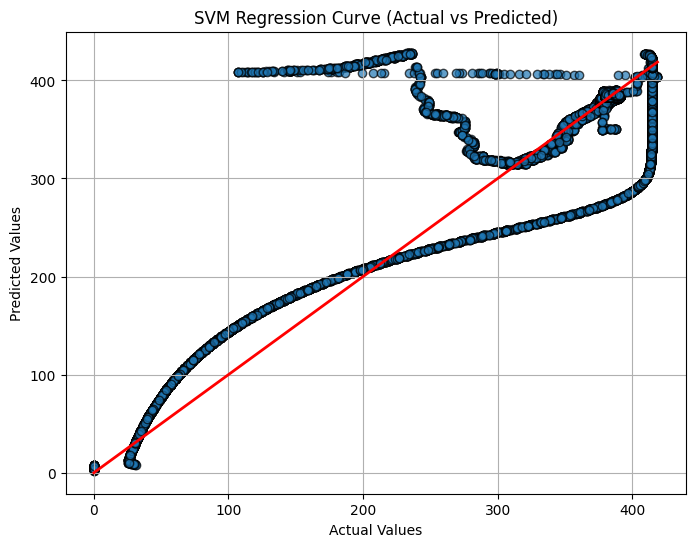

In [12]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, edgecolor='k', alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('SVM Regression Curve (Actual vs Predicted)')
plt.grid(True)
plt.show()

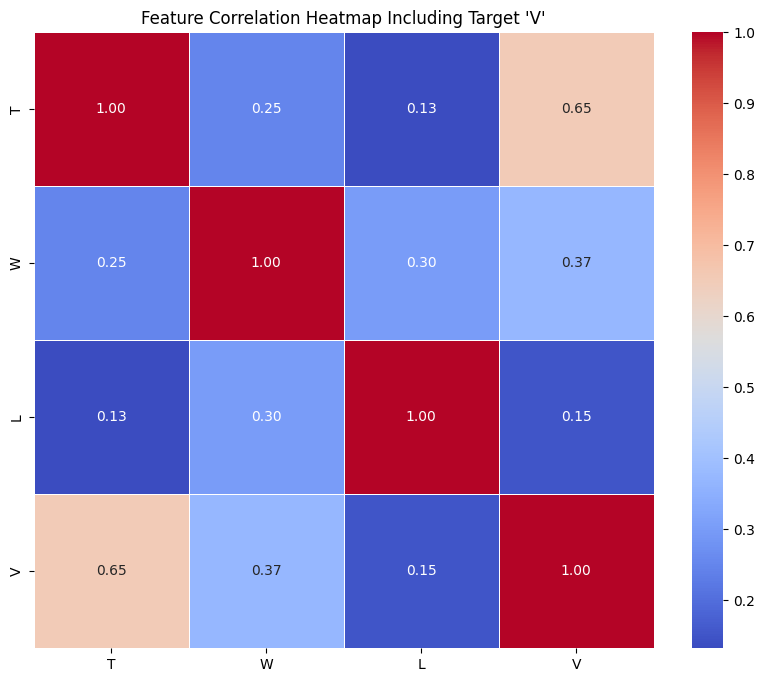

In [13]:
combined_data_with_target = pd.concat([X_train, X_test], ignore_index=True)
combined_data_with_target['V'] = pd.concat([y_train, y_test], ignore_index=True)
corr_matrix_with_target = combined_data_with_target.corr()

# Plot the heatmap including the target
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix_with_target, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Heatmap Including Target 'V'")
plt.show()

In [14]:
output = pd.DataFrame({'Switching_time(T)': test_data['T'], 'W': test_data['W'], 'L': test_data['L'], 'Actual_V': y_test, 'Predicted_PCC_Voltage': y_pred})
output.to_csv('svm_predict.csv', index=False)
print("Predictions saved to 'svm_predictions.csv'")

Predictions saved to 'svm_predictions.csv'


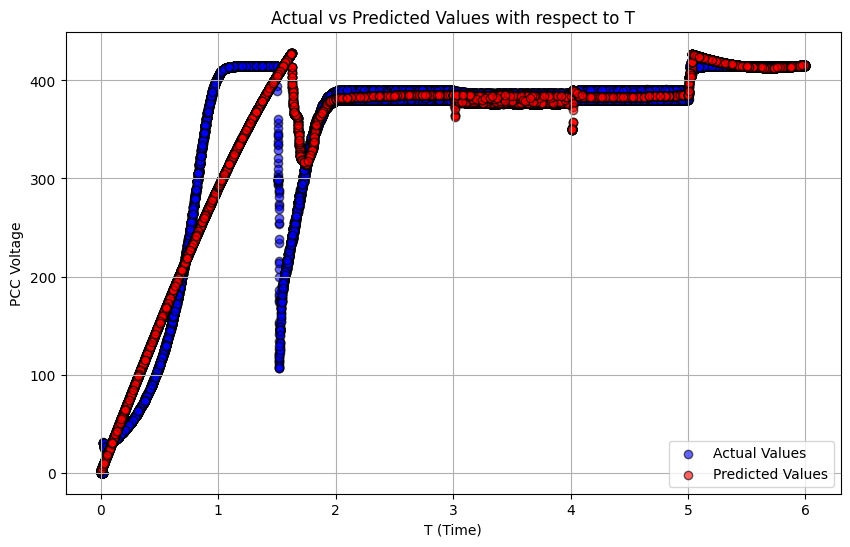

In [17]:
def plot_predictions_vs_T(X_test, y_test, y_pred, T_column_name='T'):
    """
    Function to plot both actual and predicted values against 'T' values.
    
    Args:
    - X_test: DataFrame containing test features.
    - y_test: Actual values.
    - y_pred: Array of predicted values.
    - T_column_name: Name of the 'T' column in X_test.
    """
    import matplotlib.pyplot as plt
    
    # Extract the 'T' column from the test set
    T_values = X_test[T_column_name]
    
    # Plot actual values vs T
    plt.figure(figsize=(10, 6))
    plt.scatter(T_values, y_test, color='blue', label='Actual Values', edgecolor='k', alpha=0.6)
    
    # Plot predicted values vs T
    plt.scatter(T_values, y_pred, color='red', label='Predicted Values', edgecolor='k', alpha=0.6)
    
    # Adding titles and labels
    plt.title("Actual vs Predicted Values with respect to T")
    plt.xlabel('T (Time)')
    plt.ylabel('PCC Voltage')
    
    # Add a legend to differentiate actual and predicted values
    plt.legend()
    
    # Display grid
    plt.grid(True)
    
    # Show the plot
    plt.show()

# Call the function with the actual and predicted values
plot_predictions_vs_T(X_test, y_test, y_pred, T_column_name='T')